<a href="https://colab.research.google.com/github/Small-Molecule-Discovery-Center/smdc_process_data/blob/main/Plot_LCMS_Spectra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyze data exported to excel from the LC/MS
This notebook will extract and plot m/z spectrum data exported from Advion DataExpress, and highlight some [common background peaks](https://ccc.bc.edu/content/dam/bc1/top-tier/research/VPR/research-facilities/fisher-chemical-poster.pdf). To export data, hit "Export Peaks to Excel" in DataExpress, and select "Spectrum".

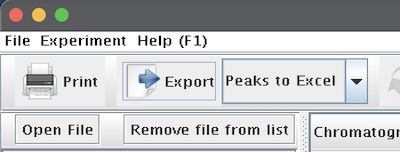


This will export *all* the peaks from every file you have open. This notebook can handle single or multiple spectra.

## How to use this notebook:
1. Process your LCMS data with Advion DataExpress and export as described above.
2. Create a CSV file with the information below ([see an example here](https://github.com/Small-Molecule-Discovery-Center/smdc_process_data/blob/main/data/example_LCMS_compound_info.csv))

|Column Name|Explanation|
|---|---|
|`sample_id`|The sample ID from the MassExpress sample list (you can copy/paste these from MassExpress)|
|`MolWt`|The molecular weight of the compound|

2. Upload your files to the colab instance
- Click the folder icon on the left toolbar then drag your input file into the folder area
3. Replace the example path with your file's path
- Right click on your file and click "copy path"
- make sure it's enclosed in the quotes when you paste it
4. Run the cell to create your plots
- click the round circle with arrow next to the cell or hit shift+enter when your cursor is anywhere in the cell
5. Download the files locally
- All files will be deleted shortly after you close the notebook instance
- If you can't see the new files, click the refresh folder icon at the top of the folder area
- You can right click and copy or save a plot
- Alternatively, change `save=False` to `save=True` and .png's will be saved for each spectrum instead of being output in the notebook.


# Plot the spectra

Cloning into 'smdc_process_data'...
remote: Enumerating objects: 274, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 274 (delta 25), reused 23 (delta 9), pack-reused 226 (from 1)
Receiving objects: 100% (274/274), 53.79 MiB | 32.42 MiB/s, done.
Resolving deltas: 100% (143/143), done.
CPU times: user 3.12 s, sys: 199 ms, total: 3.32 s
Wall time: 6.35 s


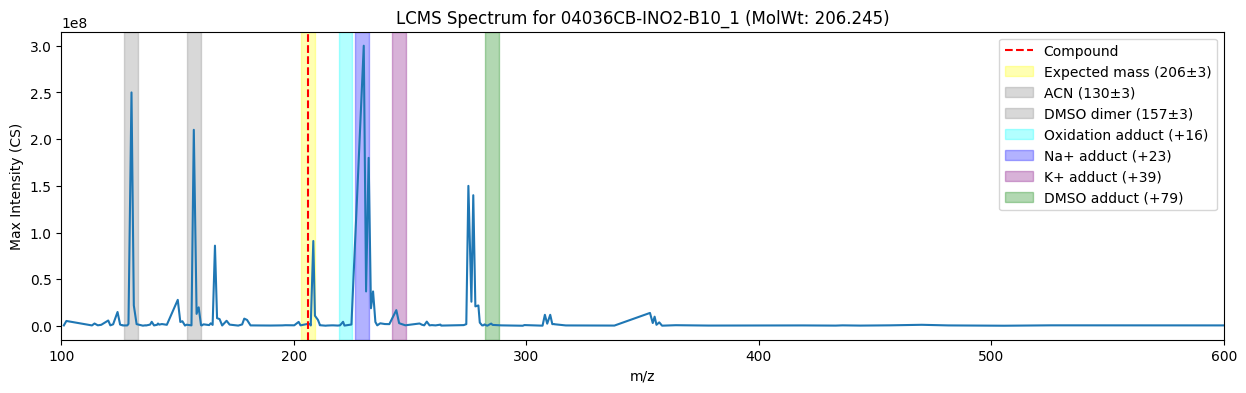

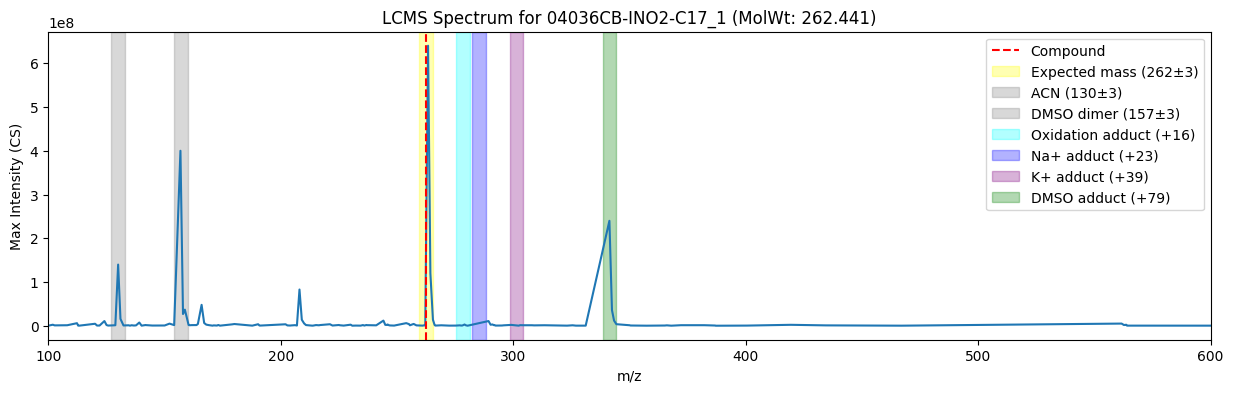

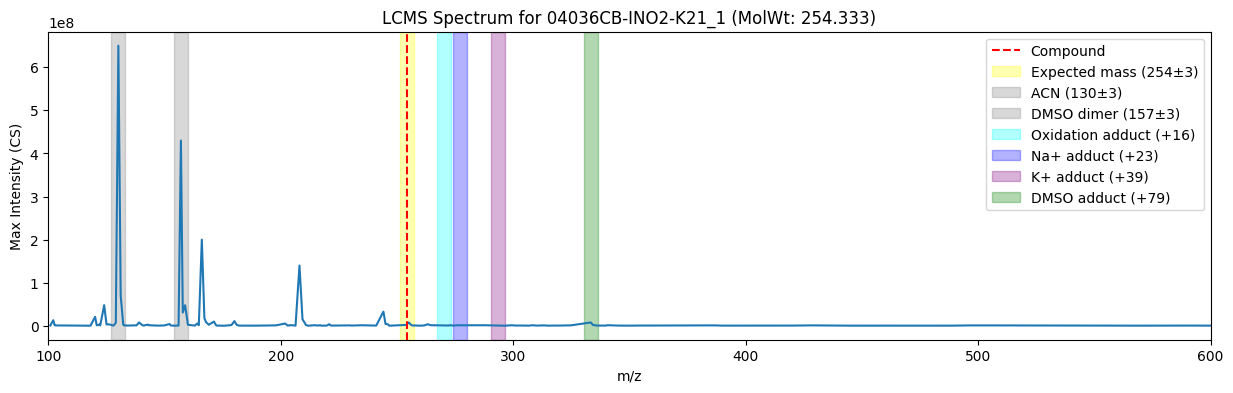

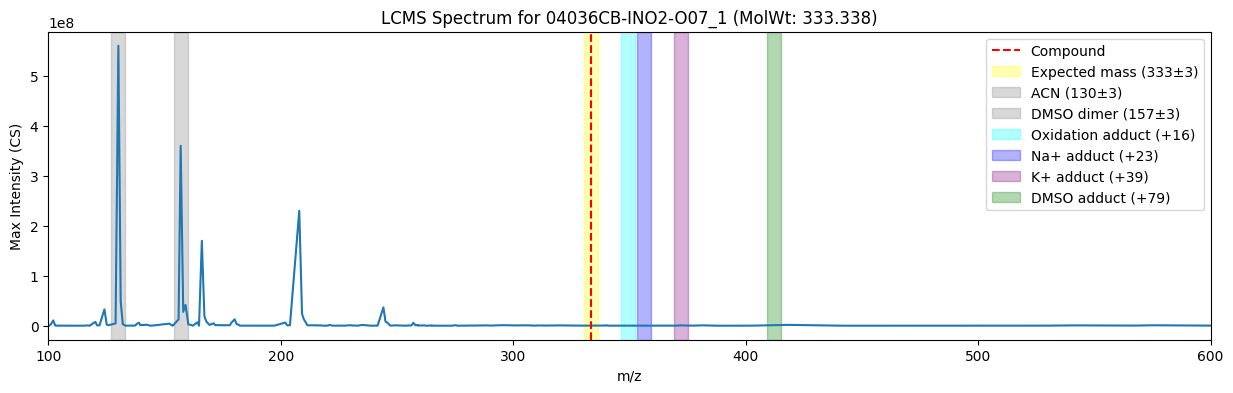

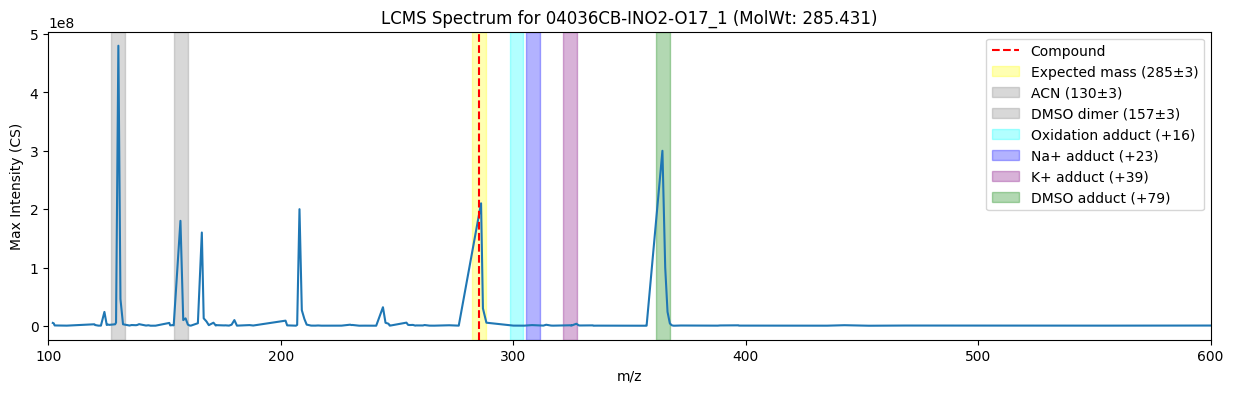

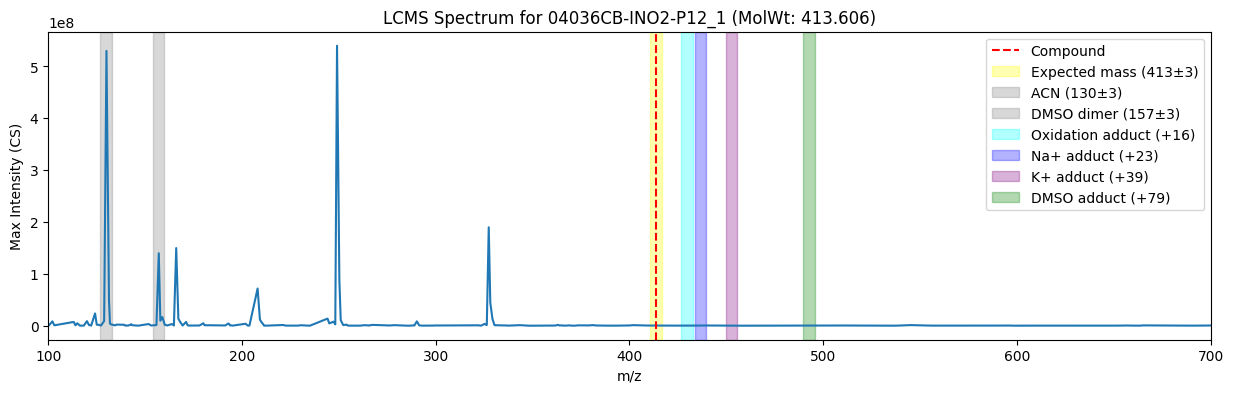

In [1]:
%%time
!git clone https://github.com/Small-Molecule-Discovery-Center/smdc_process_data.git
import pandas as pd
import sys
sys.path.append('/content/smdc_process_data')
from process_data import analyze_lcms as al

###################################
# # PASTE YOUR FILE NAMES BELOW # #
###################################
spectrum_file = "/content/smdc_process_data/data/example_LCMS_spectrum_data.xlsx"
info_file = "/content/smdc_process_data/data/example_LCMS_compound_info.csv"
###################################

data_df=al.read_lcms_results(infile=spectrum_file, kind="spectrum")
info_df=pd.read_csv(info_file)

# plot each spectra
for sample_id in info_df.sample_id.unique():
    al.plot_lcms_spectrum(info_df, data_df, sample_id, save=False) # change to True if you want to save as png's instead of output them on screen